In [1]:
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("RR cleaning environment ready")

RR cleaning environment ready


In [2]:
CHf2DB_PATH = "../data/raw/chf2db"
CHFDB_PATH = "../data/raw/chfdb"

RR_OUTPUT_PATH = "../data/processed/rr_intervals"

os.makedirs(RR_OUTPUT_PATH, exist_ok=True)

print("Output directory:", RR_OUTPUT_PATH)

Output directory: ../data/processed/rr_intervals


In [3]:
chf2db_path = "../data/raw/chf2db"
chfdb_path = "../data/raw/chfdb"
rr_output_path = "../data/processed/rr_intervals"

os.makedirs(rr_output_path, exist_ok=True)

In [4]:
def extract_rr_from_annotation(record_path, extension="ecg"):
    annotation = wfdb.rdann(
        record_path,
        extension=extension
    )

    beat_samples = annotation.sample

    rr_samples = np.diff(beat_samples)

    rr_ms = (rr_samples / annotation.fs) * 1000

    return rr_ms, annotation

In [5]:
rr_ms, annotation = extract_rr_from_annotation(
    f"{chf2db_path}/chf201"
)

print("Number of RR intervals:", len(rr_ms))
print("Mean RR:", np.mean(rr_ms))
print("Median RR:", np.median(rr_ms))

Number of RR intervals: 112232
Mean RR: 738.0360826234942
Median RR: 734.375


In [6]:
def clean_rr(rr_ms, low=300, high=2000):
    rr_ms = np.asarray(rr_ms)

    mask = (rr_ms > low) & (rr_ms < high)

    cleaned_rr = rr_ms[mask]

    removed = (~mask).sum()

    return cleaned_rr, removed

In [7]:
cleaned_rr, removed = clean_rr(rr_ms)

print("Original RR intervals:", len(rr_ms))
print("Removed:", removed)
print("Remaining:", len(cleaned_rr))

Original RR intervals: 112232
Removed: 46
Remaining: 112186


In [8]:
removed_values = rr_ms[
    (rr_ms <= 300) | (rr_ms >= 2000)
]

print("Number removed:", len(removed_values))
print("First 20 removed values:")
print(removed_values[:20])

Number removed: 46
First 20 removed values:
[ 195.3125  265.625  4648.4375  164.0625  195.3125  132.8125  250.
  187.5     187.5     195.3125  203.125   195.3125  281.25     54.6875
   93.75     85.9375  195.3125  187.5     187.5     250.    ]


In [9]:
print("Minimum before cleaning:", np.min(rr_ms))
print("Maximum before cleaning:", np.max(rr_ms))

print("Minimum after cleaning:", np.min(cleaned_rr))
print("Maximum after cleaning:", np.max(cleaned_rr))

Minimum before cleaning: 46.875
Maximum before cleaning: 5476.5625
Minimum after cleaning: 304.6875
Maximum after cleaning: 1390.625


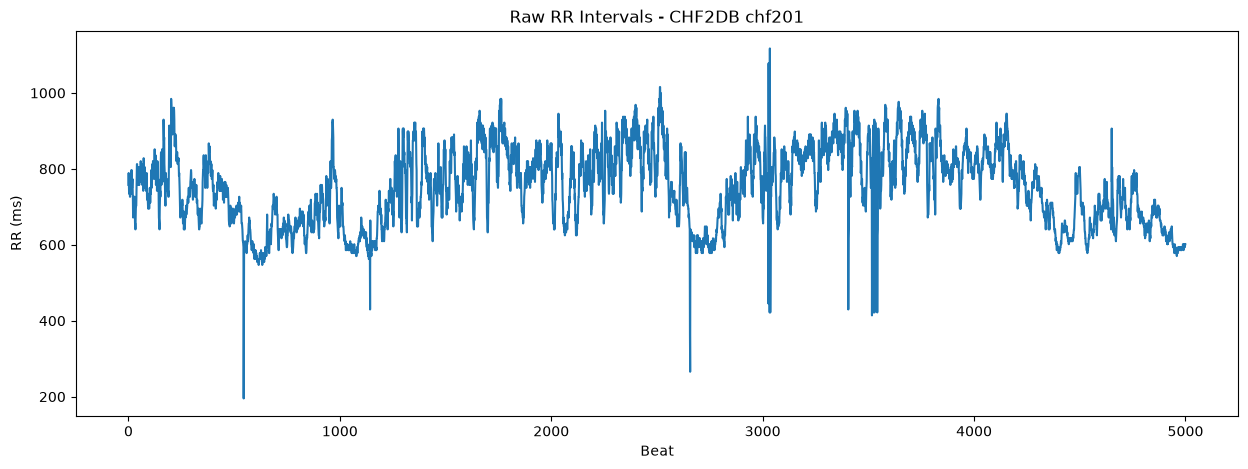

In [10]:
plt.figure(figsize=(15, 5))

plt.plot(rr_ms[:5000], label="Raw RR")

plt.title("Raw RR Intervals - CHF2DB chf201")
plt.xlabel("Beat")
plt.ylabel("RR (ms)")

plt.show()

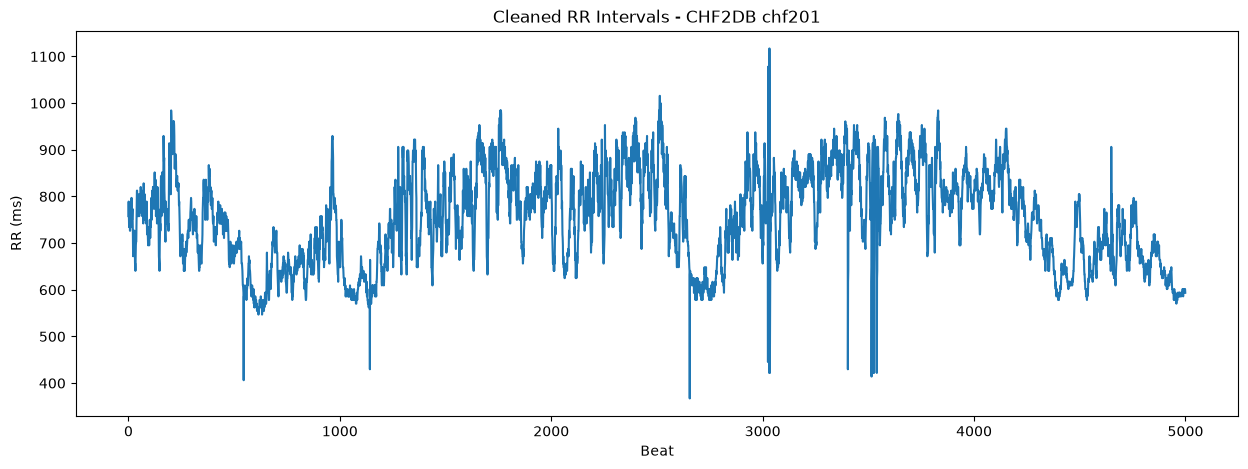

In [11]:
plt.figure(figsize=(15, 5))

plt.plot(cleaned_rr[:5000])

plt.title("Cleaned RR Intervals - CHF2DB chf201")
plt.xlabel("Beat")
plt.ylabel("RR (ms)")

plt.show()

In [12]:
cleaning_stats = {
    "patient_id": "chf201",
    "original_rr_count": len(rr_ms),
    "removed_count": removed,
    "remaining_count": len(cleaned_rr),
    "removal_percentage": (removed / len(rr_ms)) * 100,
    "lower_threshold_ms": 300,
    "upper_threshold_ms": 2000
}

cleaning_stats

{'patient_id': 'chf201',
 'original_rr_count': 112232,
 'removed_count': np.int64(46),
 'remaining_count': 112186,
 'removal_percentage': np.float64(0.040986527906479435),
 'lower_threshold_ms': 300,
 'upper_threshold_ms': 2000}

In [13]:
cleaned_df = pd.DataFrame({
    "rr_ms": cleaned_rr
})

cleaned_df.head()

,rr_ms
0,757.8125
1,789.0625
2,765.6250
3,734.3750
4,757.8125


In [14]:
cleaned_df.to_csv(
    f"{rr_output_path}/chf201_rr_cleaned.csv",
    index=False
)

In [15]:
os.path.exists(
    f"{rr_output_path}/chf201_rr_cleaned.csv"
)

True

In [16]:
stats_df = pd.DataFrame([cleaning_stats])

stats_df.to_csv(
    "../results/chf201_cleaning_stats.csv",
    index=False
)

In [17]:
def process_chf2db_record(record_name):
    
    # Extract RR intervals
    rr_ms, annotation = extract_rr_from_annotation(
        f"{chf2db_path}/{record_name}",
        extension="ecg"
    )
    
    # Clean RR intervals
    cleaned_rr, removed = clean_rr(rr_ms)
    
    # Create dataframe
    cleaned_df = pd.DataFrame({
        "rr_ms": cleaned_rr
    })
    
    # Save cleaned RR
    output_file = f"{rr_output_path}/{record_name}_rr_cleaned.csv"
    
    cleaned_df.to_csv(
        output_file,
        index=False
    )
    
    # Cleaning statistics
    stats = {
        "patient_id": record_name,
        "original_rr_count": len(rr_ms),
        "removed_count": removed,
        "remaining_count": len(cleaned_rr),
        "removal_percentage": (removed / len(rr_ms)) * 100,
        "lower_threshold_ms": 300,
        "upper_threshold_ms": 2000
    }
    
    return stats

In [18]:
chf2db_records = sorted([
    f.replace(".hea", "")
    for f in os.listdir(chf2db_path)
    if f.endswith(".hea")
])

print("Number of records:", len(chf2db_records))
print(chf2db_records)

Number of records: 29
['chf201', 'chf202', 'chf203', 'chf204', 'chf205', 'chf206', 'chf207', 'chf208', 'chf209', 'chf210', 'chf211', 'chf212', 'chf213', 'chf214', 'chf215', 'chf216', 'chf217', 'chf218', 'chf219', 'chf220', 'chf221', 'chf222', 'chf223', 'chf224', 'chf225', 'chf226', 'chf227', 'chf228', 'chf229']


In [19]:
all_stats = []

for record_name in chf2db_records:
    
    print(f"Processing {record_name}...")
    
    stats = process_chf2db_record(record_name)
    
    all_stats.append(stats)

print("Finished processing all CHF2DB records.")

Processing chf201...
Processing chf202...
Processing chf203...
Processing chf204...
Processing chf205...
Processing chf206...
Processing chf207...
Processing chf208...
Processing chf209...
Processing chf210...
Processing chf211...
Processing chf212...
Processing chf213...
Processing chf214...
Processing chf215...
Processing chf216...
Processing chf217...
Processing chf218...
Processing chf219...
Processing chf220...
Processing chf221...
Processing chf222...
Processing chf223...
Processing chf224...
Processing chf225...
Processing chf226...
Processing chf227...
Processing chf228...
Processing chf229...
Finished processing all CHF2DB records.


In [20]:
chf2db_stats = pd.DataFrame(all_stats)

chf2db_stats

,patient_id,original_rr_count,removed_count,remaining_count,removal_percentage,lower_threshold_ms,upper_threshold_ms
0,chf201,112232,46,112186,0.040987,300,2000
1,chf202,109526,185,109341,0.168910,300,2000
2,chf203,100245,983,99262,0.980598,300,2000
3,chf204,98880,260,98620,0.262945,300,2000
4,chf205,136255,1225,135030,0.899050,300,2000
5,chf206,135642,52,135590,0.038336,300,2000
6,chf207,111729,2103,109626,1.882233,300,2000
7,chf208,109277,219,109058,0.200408,300,2000
8,chf209,109545,259,109286,0.236433,300,2000
9,chf210,142023,271,141752,0.190814,300,2000


In [21]:
print("Number of patients:", len(chf2db_stats))
print("Total original RR intervals:", chf2db_stats["original_rr_count"].sum())
print("Total removed:", chf2db_stats["removed_count"].sum())

Number of patients: 29
Total original RR intervals: 3337809
Total removed: 18595


In [22]:
chf2db_stats["removal_percentage"].describe()

count    29.000000
mean      0.558942
std       0.450968
min       0.038336
25%       0.236433
50%       0.437702
75%       0.802453
max       1.882233
Name: removal_percentage, dtype: float64

In [23]:
os.makedirs("../results", exist_ok=True)

chf2db_stats.to_csv(
    "../results/chf2db_cleaning_stats.csv",
    index=False
)

In [24]:
print(
    os.path.exists(
        "../results/chf2db_cleaning_stats.csv"
    )
)

True


In [25]:
cleaned_files = [
    f for f in os.listdir(rr_output_path)
    if f.endswith("_rr_cleaned.csv")
]

print("Cleaned RR files:", len(cleaned_files))

Cleaned RR files: 29


In [26]:
print(sorted(cleaned_files))

['chf201_rr_cleaned.csv', 'chf202_rr_cleaned.csv', 'chf203_rr_cleaned.csv', 'chf204_rr_cleaned.csv', 'chf205_rr_cleaned.csv', 'chf206_rr_cleaned.csv', 'chf207_rr_cleaned.csv', 'chf208_rr_cleaned.csv', 'chf209_rr_cleaned.csv', 'chf210_rr_cleaned.csv', 'chf211_rr_cleaned.csv', 'chf212_rr_cleaned.csv', 'chf213_rr_cleaned.csv', 'chf214_rr_cleaned.csv', 'chf215_rr_cleaned.csv', 'chf216_rr_cleaned.csv', 'chf217_rr_cleaned.csv', 'chf218_rr_cleaned.csv', 'chf219_rr_cleaned.csv', 'chf220_rr_cleaned.csv', 'chf221_rr_cleaned.csv', 'chf222_rr_cleaned.csv', 'chf223_rr_cleaned.csv', 'chf224_rr_cleaned.csv', 'chf225_rr_cleaned.csv', 'chf226_rr_cleaned.csv', 'chf227_rr_cleaned.csv', 'chf228_rr_cleaned.csv', 'chf229_rr_cleaned.csv']


In [27]:
chf2db_stats.sort_values(
    "removal_percentage",
    ascending=False
)

,patient_id,original_rr_count,removed_count,remaining_count,removal_percentage,lower_threshold_ms,upper_threshold_ms
6,chf207,111729,2103,109626,1.882233,300,2000
17,chf218,107547,1587,105960,1.475634,300,2000
28,chf229,126158,1595,124563,1.264288,300,2000
21,chf222,103755,1097,102658,1.057298,300,2000
2,chf203,100245,983,99262,0.980598,300,2000
4,chf205,136255,1225,135030,0.899050,300,2000
27,chf228,120026,1000,119026,0.833153,300,2000
22,chf223,114150,916,113234,0.802453,300,2000
20,chf221,112641,861,111780,0.764375,300,2000
14,chf215,148708,991,147717,0.666407,300,2000


In [28]:
print(
    chf2db_stats[
        chf2db_stats["removal_percentage"] > 20
    ]
)

Empty DataFrame
Columns: [patient_id, original_rr_count, removed_count, remaining_count, removal_percentage, lower_threshold_ms, upper_threshold_ms]
Index: []


In [29]:
chfdb_records = sorted([
    f.replace(".hea", "")
    for f in os.listdir(chfdb_path)
    if f.endswith(".hea")
])

print("Number of CHFDB records:", len(chfdb_records))
print(chfdb_records)

Number of CHFDB records: 15
['chf01', 'chf02', 'chf03', 'chf04', 'chf05', 'chf06', 'chf07', 'chf08', 'chf09', 'chf10', 'chf11', 'chf12', 'chf13', 'chf14', 'chf15']


In [30]:
rr_ms_chfdb, annotation_chfdb = extract_rr_from_annotation(
    f"{chfdb_path}/chf01",
    extension="ecg"
)

print("Number of RR intervals:", len(rr_ms_chfdb))
print("Sampling frequency:", annotation_chfdb.fs)
print("Mean RR:", np.mean(rr_ms_chfdb))
print("Median RR:", np.median(rr_ms_chfdb))

Number of RR intervals: 75547
Sampling frequency: 250
Mean RR: 952.7490965888785
Median RR: 948.0


In [31]:
print("Minimum RR:", np.min(rr_ms_chfdb))
print("Maximum RR:", np.max(rr_ms_chfdb))

print(
    "RR < 300 ms:",
    np.sum(rr_ms_chfdb < 300)
)

print(
    "RR > 2000 ms:",
    np.sum(rr_ms_chfdb > 2000)
)

Minimum RR: 396.0
Maximum RR: 2092.0
RR < 300 ms: 0
RR > 2000 ms: 3


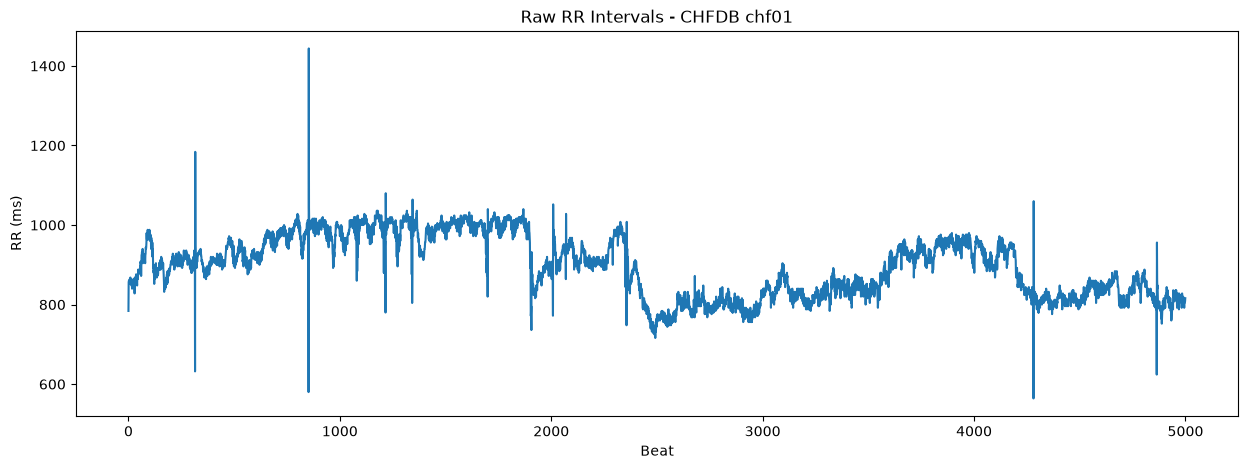

In [32]:
plt.figure(figsize=(15, 5))

plt.plot(rr_ms_chfdb[:5000])

plt.title("Raw RR Intervals - CHFDB chf01")
plt.xlabel("Beat")
plt.ylabel("RR (ms)")

plt.show()

In [33]:
def process_chfdb_record(record_name):
    
    # Extract RR intervals
    rr_ms, annotation = extract_rr_from_annotation(
        f"{chfdb_path}/{record_name}",
        extension="ecg"
    )
    
    # Clean RR intervals
    cleaned_rr, removed = clean_rr(rr_ms)
    
    # Create dataframe
    cleaned_df = pd.DataFrame({
        "rr_ms": cleaned_rr
    })
    
    # Save cleaned RR
    output_file = f"{rr_output_path}/{record_name}_rr_cleaned.csv"
    
    cleaned_df.to_csv(
        output_file,
        index=False
    )
    
    # Cleaning statistics
    stats = {
        "patient_id": record_name,
        "original_rr_count": len(rr_ms),
        "removed_count": removed,
        "remaining_count": len(cleaned_rr),
        "removal_percentage": (removed / len(rr_ms)) * 100,
        "lower_threshold_ms": 300,
        "upper_threshold_ms": 2000
    }
    
    return stats

In [34]:
chfdb_all_stats = []

for record_name in chfdb_records:
    
    print(f"Processing {record_name}...")
    
    stats = process_chfdb_record(record_name)
    
    chfdb_all_stats.append(stats)

print("Finished processing all CHFDB records.")

Processing chf01...
Processing chf02...
Processing chf03...
Processing chf04...
Processing chf05...
Processing chf06...
Processing chf07...
Processing chf08...
Processing chf09...
Processing chf10...
Processing chf11...
Processing chf12...
Processing chf13...
Processing chf14...
Processing chf15...
Finished processing all CHFDB records.


In [35]:
chfdb_stats = pd.DataFrame(chfdb_all_stats)

chfdb_stats

,patient_id,original_rr_count,removed_count,remaining_count,removal_percentage,lower_threshold_ms,upper_threshold_ms
0,chf01,75547,3,75544,0.003971,300,2000
1,chf02,114547,32,114515,0.027936,300,2000
2,chf03,81300,220,81080,0.270603,300,2000
3,chf04,112365,23,112342,0.020469,300,2000
4,chf05,119152,2,119150,0.001679,300,2000
5,chf06,118633,302,118331,0.254567,300,2000
6,chf07,92583,23,92560,0.024843,300,2000
7,chf08,90758,32,90726,0.035259,300,2000
8,chf09,115051,46,115005,0.039982,300,2000
9,chf10,147304,161,147143,0.109298,300,2000


In [36]:
print("Number of patients:", len(chfdb_stats))
print(
    "Total original RR intervals:",
    chfdb_stats["original_rr_count"].sum()
)
print(
    "Total removed:",
    chfdb_stats["removed_count"].sum()
)

Number of patients: 15
Total original RR intervals: 1622525
Total removed: 929


In [37]:
chfdb_stats.to_csv(
    "../results/chfdb_cleaning_stats.csv",
    index=False
)

In [38]:
print(
    os.path.exists(
        "../results/chfdb_cleaning_stats.csv"
    )
)

True


In [39]:
cleaned_files = [
    f for f in os.listdir(rr_output_path)
    if f.endswith("_rr_cleaned.csv")
]

print("Total cleaned RR files:", len(cleaned_files))

Total cleaned RR files: 44


In [41]:
cleaned_files = [
    f for f in os.listdir(rr_output_path)
    if f.endswith("_rr_cleaned.csv")
]

chf2db_cleaned = [
    f for f in cleaned_files
    if f.startswith("chf2")
]

chfdb_cleaned = [
    f for f in cleaned_files
    if f.startswith("chf0") or f.startswith("chf1")
]

print("Total cleaned RR files:", len(cleaned_files))
print("CHF2DB files:", len(chf2db_cleaned))
print("CHFDB files:", len(chfdb_cleaned))

Total cleaned RR files: 44
CHF2DB files: 29
CHFDB files: 15
